# Bijection: Subforests ↔ Distinct Degree Sequences

**Goal**: For a graph $G$, we construct an explicit bijection
$$f: \{\text{spanning subforests of } G\} \to \{\text{distinct degree sequences of all spanning subgraphs of } G\}$$
and verify that both sets have the same size.

**Method**: Induct on edges of $G$. When we add the last edge $e_n$ to $G_{n-1}$:
- Subforests **not** containing $e_n$ extend their mapping from $f_{n-1}$ unchanged.
- Subforests **containing** $e_n$: remove $e_n$, apply $f_{n-1}$, re-add $e_n$, then **complete any alternating cycle** that $e_n$ closes.

An *alternating cycle* in subgraph $H$ w.r.t. cycle $C$ means $H$ contains every other edge of $C$. Completing it swaps the in/out edges around $C$, changing the mapped subgraph while preserving injectivity on degree sequences.

In [27]:
from itertools import combinations
from sage.all import BipartiteGraph, Graph

## Helper Functions

In [28]:
def all_subgraphs(G):
    """
    Enumerate all 2^|E| spanning subgraphs of G (all vertex-subsets of edges).
    Each subgraph keeps ALL vertices of G so degree sequences are comparable.
    """
    edges = G.edges(labels=True)
    V = G.vertices()
    subgraphs = []
    for k in range(len(edges) + 1):
        for E in combinations(edges, k):
            H = Graph()
            H.add_vertices(V)
            H.add_edges(E)
            subgraphs.append(H)
    return subgraphs

In [29]:
def make_cycles(G):
    """
    Return all simple cycles of G as lists of edges (u, v).

    We copy G into a plain Graph (stripping labels and BipartiteGraph quirks)
    so that all_simple_cycles(algorithm='B') works reliably on undirected graphs.
    Algorithm 'B' (Johnson's) is required for undirected simple cycles.
    """
    H = Graph()
    H.add_vertices(list(G.vertices()))
    # Add edges as sorted (u,v) pairs to normalize direction
    H.add_edges(tuple(sorted((u, v))) for u, v, _ in G.edges(labels=True))

    raw_cycles = H.all_simple_cycles(algorithm='B')

    # Each cycle from SageMath is a vertex list [v0, v1, ..., vk, v0]
    # Convert to edge list [(v0,v1), (v1,v2), ..., (vk,v0)]
    result = []
    for c in raw_cycles:
        edge_list = [(c[i], c[i + 1]) for i in range(len(c) - 1)]
        result.append(edge_list)
    return result

In [30]:
def _sorted_uv(u, v):
    """Normalize an edge so smaller vertex comes first."""
    return (min(u, v), max(u, v))


def find_alt_cycles(G):
    """
    Find all spanning subgraphs of G that are alternating on at least one cycle.

    A subgraph H is *alternating* on cycle C if H contains every other edge of C
    and misses the remaining edges of C (either parity works).

    Returns a list of Graph objects.
    """
    cycles = make_cycles(G)
    alt_cycles = []

    for H in all_subgraphs(G):
        h_edges = {_sorted_uv(u, v) for u, v, _ in H.edges(labels=True)}
        for cyc in cycles:
            c = [_sorted_uv(a, b) for a, b in cyc]
            c1, c2 = c[::2], c[1::2]   # the two alternating halves
            parity1 = all(e in h_edges for e in c1) and all(e not in h_edges for e in c2)
            parity2 = all(e in h_edges for e in c2) and all(e not in h_edges for e in c1)
            if parity1 or parity2:
                alt_cycles.append(H)
                break

    return alt_cycles


def _add_labeled_edge_from_G(H, G, ab):
    """Add the edge of G whose sorted endpoints equal ab, carrying its label."""
    for u, v, lab in G.edges(labels=True):
        if _sorted_uv(u, v) == ab:
            H.add_edge(u, v, lab)
            return


def complete_alt_cycles(H, G, new_labeled_edge):
    """
    After re-attaching new_labeled_edge to H, complete any alternating cycle
    in G that passes through that edge.

    When multiple cycles through new_labeled_edge are simultaneously alternating,
    we complete the LONGEST one. This is the key injectivity rule: the longer
    cycle produces a degree sequence that is otherwise unreachable from any other
    forest, preventing collisions in the bijection image.

    Parameters
    ----------
    H                : Graph — subgraph after re-adding the new edge
    G                : Graph — the parent graph (defines cycles and labels)
    new_labeled_edge : (u, v, label) — the edge that was re-attached

    Returns a new Graph (copy of H, possibly with extra edges).
    """
    n_pair = _sorted_uv(new_labeled_edge[0], new_labeled_edge[1])
    h_prime = H.copy()

    # Sort longest first: when multiple cycles through new_labeled_edge are
    # alternating in H, the longest cycle wins.
    for cyc in sorted(make_cycles(G), key=len, reverse=True):
        c = [_sorted_uv(a, b) for a, b in cyc]

        if n_pair not in c:
            continue

        c1, c2 = c[::2], c[1::2]
        h_edges = {_sorted_uv(u, v) for u, v, _ in h_prime.edges(labels=True)}

        completed = False

        if n_pair in c1:
            if all(e in h_edges for e in c1) and all(e not in h_edges for e in c2):
                print(f"      → Alternating cycle found (len={len(cyc)})! Adding missing half: {c2}")
                for edge_pair in c2:
                    _add_labeled_edge_from_G(h_prime, G, edge_pair)
                completed = True

        elif n_pair in c2:
            if all(e in h_edges for e in c2) and all(e not in h_edges for e in c1):
                print(f"      → Alternating cycle found (len={len(cyc)})! Adding missing half: {c1}")
                for edge_pair in c1:
                    _add_labeled_edge_from_G(h_prime, G, edge_pair)
                completed = True

        if completed:
            break  # longest alternating cycle found — stop here

    return h_prime

## Edge-Label Indicator Representation

To track subgraphs as dictionary keys and compare them, we represent each spanning subgraph as a **0-1 indicator tuple** indexed by the parent graph's edge labels (sorted).

Example: If G has edges labeled `'1','2','3','4'`, then the subgraph containing edges `'1'` and `'3'` is represented as `(1, 0, 1, 0)`.

In [31]:
def parent_edge_order(G):
    """
    Build the canonical edge-label ordering for G.

    Returns
    -------
    all_labels   : sorted list of all edge labels in G
    label_to_edge: dict mapping label -> (u, v)
    """
    all_labels = sorted(label for _, _, label in G.edges(labels=True))
    label_to_edge = {label: (u, v) for u, v, label in G.edges(labels=True)}
    return all_labels, label_to_edge


def graph_to_indicator_tuple(H, edge_labels):
    """
    Convert a spanning subgraph H into a 0-1 indicator tuple.

    edge_labels must be the parent graph's label list (from parent_edge_order)
    so that every subgraph uses the same coordinate system.
    """
    present = {lab for _, _, lab in H.edges(labels=True)}
    return tuple(1 if lab in present else 0 for lab in edge_labels)


def indicator_tuple_to_graph(indicator, edge_labels, label_to_edge):
    """
    Reconstruct a Graph from its indicator tuple.
    All vertices from label_to_edge are included (isolated vertices preserved).
    """
    edges = [
        (label_to_edge[lab][0], label_to_edge[lab][1], lab)
        for lab, val in zip(edge_labels, indicator)
        if val == 1
    ]
    vertices = set()
    for u, v in label_to_edge.values():
        vertices.update([u, v])

    G = Graph()
    G.add_vertices(sorted(vertices))
    G.add_edges(edges)
    return G

## The Recursive Bijection `getf`

**Recursive definition** of $f_G: 2^{E(G)} \to 2^{E(G)}$ (where we index subgraphs by indicator tuples):

1. **Base case** — $G$ is a forest: $f_G(H) = H$ for every spanning subgraph $H$.
2. **Recursive case** — let $e_n$ be the last edge (by label) and $G' = G \setminus e_n$:
   - If $e_n \notin H$: $f_G(H) = f_{G'}(H)$
   - If $e_n \in H$: let $H' = H \setminus e_n$. Then
     $$f_G(H) = \text{completeAltCycles}(f_{G'}(H') \cup \{e_n\},\; G,\; e_n)$$

**Key property**: when restricted to spanning forests of $G$, $f_G$ is injective and its images have pairwise distinct degree sequences.

In [32]:
def getf(G, root_labels=None, label_to_edge=None, verbose=False):
    """
    Build the bijection f_G as a dictionary:
        indicator tuple of H  ->  Graph object f_G(H)

    Keys cover ALL 2^|E| spanning subgraphs.
    The restriction to forests gives the bijection we care about.

    Parameters
    ----------
    G           : the graph to process
    root_labels : edge-label list from the top-level call (pinned once)
    label_to_edge: dict from the top-level call (pinned once)
    verbose     : if True, print each mapping step
    """
    # Pin the coordinate system on the first (top-level) call
    if root_labels is None:
        root_labels, label_to_edge = parent_edge_order(G)

    # BASE CASE: G itself is a forest — identity map
    if G.is_forest():
        if verbose:
            print(f"  [Base] G is a forest with edges {sorted(lab for _,_,lab in G.edges(labels=True))}")
            print(f"         Using identity map for all {2**G.size()} spanning subgraphs.")
        f = {}
        for H in all_subgraphs(G):
            t = graph_to_indicator_tuple(H, root_labels)
            f[t] = H.copy()
        return f

    # RECURSIVE CASE: peel off the last edge (highest label)
    edges_sorted = sorted(G.edges(labels=True), key=lambda e: e[2])
    e_last = edges_sorted[-1]          # the edge we are "adding" at this level
    lab_last = e_last[2]

    if verbose:
        print(f"  [Recurse] Peeling edge '{lab_last}' = {e_last[:2]}. "
              f"Remaining edges: {[e[2] for e in edges_sorted[:-1]]}")

    # Recurse on G minus the last edge
    G_minus = G.copy()
    G_minus.delete_edge(e_last)
    f_prev = getf(G_minus, root_labels, label_to_edge, verbose=verbose)

    f = {}
    for H in all_subgraphs(G):
        t = graph_to_indicator_tuple(H, root_labels)
        h_labels = {lab for _, _, lab in H.edges(labels=True)}

        if lab_last not in h_labels:
            # H does not use e_last: inherit from f_prev unchanged
            f[t] = f_prev[t].copy()
        else:
            # H uses e_last: apply recursive step
            H_minus = H.copy()
            H_minus.delete_edge(e_last)
            t_minus = graph_to_indicator_tuple(H_minus, root_labels)

            # Start from f_prev(H \ e_last), then re-attach e_last
            base = f_prev[t_minus].copy()
            base.add_edge(e_last)

            if verbose:
                h_edges = sorted(h_labels)
                base_edges = sorted(lab for _, _, lab in base.edges(labels=True))
                print(f"    H={h_edges}: base after re-attaching '{lab_last}' = {base_edges}")

            # Complete any alternating cycle that passes through e_last
            f[t] = complete_alt_cycles(base, G, e_last)

    return f

In [33]:
def degree_tuple(H, parent_vertices):
    """
    Degree sequence of H in a fixed vertex order (sorted parent_vertices).

    Using the PARENT graph's vertex order ensures that two subgraphs
    with the same degree at every vertex get the same tuple, even if
    H.vertices() returns them in different orders.
    """
    return tuple(H.degree(v) for v in sorted(parent_vertices))

---
## Demo 1: The 4-Cycle $C_4$ (= $K_{2,2}$)

The simplest non-forest bipartite graph.

- 4 vertices, 4 edges, one cycle.
- $2^4 = 16$ spanning subgraphs.
- All spanning subgraphs except the full cycle are forests → **15 forests**.
- We expect to find exactly **15 distinct degree sequences** among all 16 subgraphs.

C4 (bipartite K_{2,2}):
  Vertices : [0, 1, 2, 3]
  Edges    : [(0, 2, '1'), (0, 3, '2'), (1, 2, '3'), (1, 3, '4')]
  Is bipartite: True
  Is forest   : False



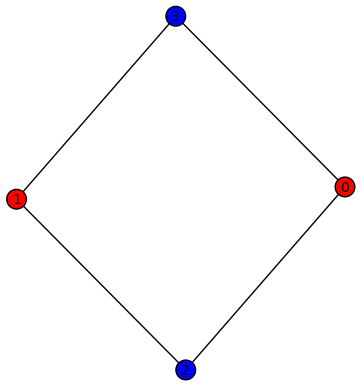

In [34]:
# Build C4 as a bipartite graph: left={0,1}, right={2,3}
# Pass the adjacency dict + partition together (required by SageMath's BipartiteGraph),
# then assign edge labels with set_edge_label.
partition_c4 = [[0, 1], [2, 3]]
C4 = BipartiteGraph({0: [2, 3], 1: [2, 3]}, partition_c4)
C4.set_edge_label(0, 2, '1')
C4.set_edge_label(0, 3, '2')
C4.set_edge_label(1, 2, '3')
C4.set_edge_label(1, 3, '4')

print("C4 (bipartite K_{2,2}):")
print(f"  Vertices : {C4.vertices()}")
print(f"  Edges    : {[(u,v,lab) for u,v,lab in sorted(C4.edges(labels=True), key=lambda e: e[2])]}")
print(f"  Is bipartite: {C4.is_bipartite()}")
print(f"  Is forest   : {C4.is_forest()}")
print()
C4.show(vertex_colors={'red': partition_c4[0], 'blue': partition_c4[1]})

In [35]:
# Identify all spanning forests (acyclic subgraphs) of C4
all_subs_c4 = all_subgraphs(C4)
forests_c4 = [H for H in all_subs_c4 if H.is_forest()]

print(f"Total spanning subgraphs of C4 : {len(all_subs_c4)}  (= 2^4)")
print(f"Spanning forests of C4         : {len(forests_c4)}")
print()

# List every forest with its edge set
root_labels_c4, label_to_edge_c4 = parent_edge_order(C4)
print("Edge label order:", root_labels_c4)
print()
print("All spanning forests of C4 (by indicator tuple):")
for H in forests_c4:
    t = graph_to_indicator_tuple(H, root_labels_c4)
    edge_labs = sorted(lab for _, _, lab in H.edges(labels=True))
    deg = degree_tuple(H, C4.vertices())
    print(f"  {t}  edges={edge_labs}  degree_seq={deg}")

Total spanning subgraphs of C4 : 16  (= 2^4)
Spanning forests of C4         : 15

Edge label order: ['1', '2', '3', '4']

All spanning forests of C4 (by indicator tuple):
  (0, 0, 0, 0)  edges=[]  degree_seq=(0, 0, 0, 0)
  (1, 0, 0, 0)  edges=['1']  degree_seq=(1, 0, 1, 0)
  (0, 1, 0, 0)  edges=['2']  degree_seq=(1, 0, 0, 1)
  (0, 0, 1, 0)  edges=['3']  degree_seq=(0, 1, 1, 0)
  (0, 0, 0, 1)  edges=['4']  degree_seq=(0, 1, 0, 1)
  (1, 1, 0, 0)  edges=['1', '2']  degree_seq=(2, 0, 1, 1)
  (1, 0, 1, 0)  edges=['1', '3']  degree_seq=(1, 1, 2, 0)
  (1, 0, 0, 1)  edges=['1', '4']  degree_seq=(1, 1, 1, 1)
  (0, 1, 1, 0)  edges=['2', '3']  degree_seq=(1, 1, 1, 1)
  (0, 1, 0, 1)  edges=['2', '4']  degree_seq=(1, 1, 0, 2)
  (0, 0, 1, 1)  edges=['3', '4']  degree_seq=(0, 2, 1, 1)
  (1, 1, 1, 0)  edges=['1', '2', '3']  degree_seq=(2, 1, 2, 1)
  (1, 1, 0, 1)  edges=['1', '2', '4']  degree_seq=(2, 1, 1, 2)
  (1, 0, 1, 1)  edges=['1', '3', '4']  degree_seq=(1, 2, 2, 1)
  (0, 1, 1, 1)  edges=['2', '3

In [36]:
# Verify: count distinct degree sequences of ALL subgraphs of C4
all_deg_seqs_c4 = {degree_tuple(H, C4.vertices()) for H in all_subs_c4}
print(f"Distinct degree sequences of ALL subgraphs of C4: {len(all_deg_seqs_c4)}")
print("They are:")
for d in sorted(all_deg_seqs_c4):
    print(f"  {d}")
print()
print(f"Number of forests = {len(forests_c4)},  "
      f"distinct degree sequences = {len(all_deg_seqs_c4)}")
print("Match!", len(forests_c4) == len(all_deg_seqs_c4))

Distinct degree sequences of ALL subgraphs of C4: 15
They are:
  (0, 0, 0, 0)
  (0, 1, 0, 1)
  (0, 1, 1, 0)
  (0, 2, 1, 1)
  (1, 0, 0, 1)
  (1, 0, 1, 0)
  (1, 1, 0, 2)
  (1, 1, 1, 1)
  (1, 1, 2, 0)
  (1, 2, 1, 2)
  (1, 2, 2, 1)
  (2, 0, 1, 1)
  (2, 1, 1, 2)
  (2, 1, 2, 1)
  (2, 2, 2, 2)

Number of forests = 15,  distinct degree sequences = 15
Match! True


In [37]:
# Run getf on C4 with verbose output to see the alternating-cycle step
print("=" * 60)
print("Running getf(C4) with verbose=True")
print("(Only subgraphs containing edge '4' trigger the recursive step)")
print("=" * 60)
f_c4 = getf(C4, verbose=True)

Running getf(C4) with verbose=True
(Only subgraphs containing edge '4' trigger the recursive step)
  [Recurse] Peeling edge '4' = (1, 3). Remaining edges: ['1', '2', '3']
  [Base] G is a forest with edges ['1', '2', '3']
         Using identity map for all 8 spanning subgraphs.
    H=['4']: base after re-attaching '4' = ['4']
    H=['1', '4']: base after re-attaching '4' = ['1', '4']
      → Alternating cycle found (len=4)! Adding missing half: [(1, 2), (0, 3)]
    H=['2', '4']: base after re-attaching '4' = ['2', '4']
    H=['3', '4']: base after re-attaching '4' = ['3', '4']
    H=['1', '2', '4']: base after re-attaching '4' = ['1', '2', '4']
    H=['1', '3', '4']: base after re-attaching '4' = ['1', '3', '4']
    H=['2', '3', '4']: base after re-attaching '4' = ['2', '3', '4']
    H=['1', '2', '3', '4']: base after re-attaching '4' = ['1', '2', '3', '4']


In [38]:
# Display the full bijection table for forests of C4
print("=" * 80)
print("BIJECTION TABLE: Forest H  →  f(H)  →  degree sequence of f(H)")
print("Vertex order for degree sequences:", sorted(C4.vertices()))
print("=" * 80)
print(f"{'Forest edges':<25} {'Indicator':<15} {'f(H) edges':<30} {'deg(f(H))':<20}")
print("-" * 90)

image_deg_seqs = set()

for H in forests_c4:
    t = graph_to_indicator_tuple(H, root_labels_c4)
    fH = f_c4[t]
    forest_edges = str(sorted(lab for _, _, lab in H.edges(labels=True)))
    image_edges  = str(sorted(lab for _, _, lab in fH.edges(labels=True)))
    deg = degree_tuple(fH, C4.vertices())
    image_deg_seqs.add(deg)

    # Flag if f(H) is not a forest (demonstrates the alternating-cycle step)
    note = "  ← cycle completed!" if not fH.is_forest() else ""
    print(f"  {forest_edges:<23} {str(t):<15} {image_edges:<30} {str(deg):<20}{note}")

print("-" * 90)
print(f"\nForests: {len(forests_c4)}")
print(f"Distinct degree sequences in image: {len(image_deg_seqs)}")
print("Bijection holds:", len(forests_c4) == len(image_deg_seqs) == len(all_deg_seqs_c4))

BIJECTION TABLE: Forest H  →  f(H)  →  degree sequence of f(H)
Vertex order for degree sequences: [0, 1, 2, 3]
Forest edges              Indicator       f(H) edges                     deg(f(H))           
------------------------------------------------------------------------------------------
  []                      (0, 0, 0, 0)    []                             (0, 0, 0, 0)        
  ['1']                   (1, 0, 0, 0)    ['1']                          (1, 0, 1, 0)        
  ['2']                   (0, 1, 0, 0)    ['2']                          (1, 0, 0, 1)        
  ['3']                   (0, 0, 1, 0)    ['3']                          (0, 1, 1, 0)        
  ['4']                   (0, 0, 0, 1)    ['4']                          (0, 1, 0, 1)        
  ['1', '2']              (1, 1, 0, 0)    ['1', '2']                     (2, 0, 1, 1)        
  ['1', '3']              (1, 0, 1, 0)    ['1', '3']                     (1, 1, 2, 0)        
  ['1', '4']              (1, 0, 0, 1)    ['1'

### Observation

The forest `['2', '4']` (edges `(0,3)` and `(1,2)`) forms an **alternating matching** on the 4-cycle. After re-attaching edge `'4'`, the base subgraph alternates on the cycle, so `complete_alt_cycles` adds the missing edges `['1','3']`, mapping this forest to the **full 4-cycle** with degree sequence `(2,2,2,2)`. This is the unique way the degree sequence `(2,2,2,2)` enters the image — without the bijection we would not "see" it from any forest.

---
## Demo 2: 4-Cycle with 2 Isolated Vertices ($G_4$ from testing notebook)

Bipartite graph with:
- Left: `{1, 4, 5}`, Right: `{2, 3, 6}`
- Edges: 1-2, 1-3, 2-4, 3-4  (a 4-cycle on vertices 1,2,3,4)
- Vertices 5, 6 are isolated

Expected: **15 forests**, **15 distinct degree sequences**.

G4:
  Vertices : [1, 2, 3, 4, 5, 6]
  Edges    : [(1, 2, '1'), (1, 3, '2'), (2, 4, '3'), (3, 4, '4')]
  Is forest: False


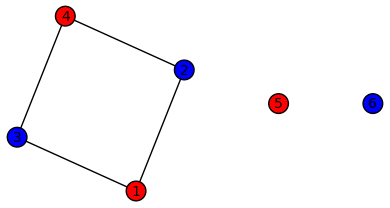

In [39]:
partition_g4 = [[1, 4, 5], [2, 3, 6]]
G4 = BipartiteGraph({1: [2, 3], 4: [2, 3], 5: [], 6: []}, partition_g4)
G4.set_edge_label(1, 2, '1')
G4.set_edge_label(1, 3, '2')
G4.set_edge_label(2, 4, '3')
G4.set_edge_label(3, 4, '4')

color_dict_g4 = {'red': partition_g4[0], 'blue': partition_g4[1]}

print("G4:")
print(f"  Vertices : {sorted(G4.vertices())}")
print(f"  Edges    : {[(u,v,lab) for u,v,lab in sorted(G4.edges(labels=True), key=lambda e: e[2])]}")
print(f"  Is forest: {G4.is_forest()}")
G4.show(vertex_colors=color_dict_g4)

In [40]:
# Count forests and distinct degree sequences
all_subs_g4 = all_subgraphs(G4)
forests_g4  = [H for H in all_subs_g4 if H.is_forest()]

# IMPORTANT: use sorted(G4.vertices()) as the fixed vertex order
parent_verts_g4 = sorted(G4.vertices())
all_deg_seqs_g4 = {degree_tuple(H, parent_verts_g4) for H in all_subs_g4}

print(f"Total spanning subgraphs : {len(all_subs_g4)}")
print(f"Spanning forests         : {len(forests_g4)}")
print(f"Distinct degree sequences (vertex order {parent_verts_g4}): {len(all_deg_seqs_g4)}")
print("Match!", len(forests_g4) == len(all_deg_seqs_g4))

Total spanning subgraphs : 16
Spanning forests         : 15
Distinct degree sequences (vertex order [1, 2, 3, 4, 5, 6]): 15
Match! True


In [41]:
# Run the bijection on G4
print("Running getf(G4)...")
root_labels_g4, label_to_edge_g4 = parent_edge_order(G4)
f_g4 = getf(G4, verbose=False)
print("Done.")
print()

# Display bijection table for G4
print("=" * 80)
print("BIJECTION TABLE for G4")
print(f"Vertex order: {parent_verts_g4}")
print("=" * 80)
print(f"{'Forest edges':<20} {'Indicator':<12} {'f(H) edges':<25} {'deg(f(H))':<30}")
print("-" * 90)

image_deg_seqs_g4 = set()

for H in forests_g4:
    t = graph_to_indicator_tuple(H, root_labels_g4)
    fH = f_g4[t]
    forest_edges = str(sorted(lab for _, _, lab in H.edges(labels=True)))
    image_edges  = str(sorted(lab for _, _, lab in fH.edges(labels=True)))
    deg = degree_tuple(fH, parent_verts_g4)
    image_deg_seqs_g4.add(deg)
    note = "  ← cycle completed!" if not fH.is_forest() else ""
    print(f"  {forest_edges:<18} {str(t):<12} {image_edges:<25} {str(deg):<30}{note}")

print("-" * 90)
print(f"\nForests: {len(forests_g4)}")
print(f"Distinct degree sequences in image: {len(image_deg_seqs_g4)}")
print("Images cover ALL subgraph degree sequences:", image_deg_seqs_g4 == all_deg_seqs_g4)
print("Bijection holds:", len(forests_g4) == len(image_deg_seqs_g4) == len(all_deg_seqs_g4))

Running getf(G4)...
      → Alternating cycle found (len=4)! Adding missing half: [(2, 4), (1, 3)]
Done.

BIJECTION TABLE for G4
Vertex order: [1, 2, 3, 4, 5, 6]
Forest edges         Indicator    f(H) edges                deg(f(H))                     
------------------------------------------------------------------------------------------
  []                 (0, 0, 0, 0) []                        (0, 0, 0, 0, 0, 0)            
  ['1']              (1, 0, 0, 0) ['1']                     (1, 1, 0, 0, 0, 0)            
  ['2']              (0, 1, 0, 0) ['2']                     (1, 0, 1, 0, 0, 0)            
  ['3']              (0, 0, 1, 0) ['3']                     (0, 1, 0, 1, 0, 0)            
  ['4']              (0, 0, 0, 1) ['4']                     (0, 0, 1, 1, 0, 0)            
  ['1', '2']         (1, 1, 0, 0) ['1', '2']                (2, 1, 1, 0, 0, 0)            
  ['1', '3']         (1, 0, 1, 0) ['1', '3']                (1, 2, 0, 1, 0, 0)            
  ['1', '4']       

---
## Demo 3: Larger Bipartite Graph (7 edges)

The full graph $G$ from the testing notebook:
- Left: `{1, 4, 5}`, Right: `{2, 3, 6}`
- 7 edges: 1-2, 1-3, 2-4, 3-4, 4-6, 5-6, 3-5
- Multiple cycles

We just verify the count, not print every mapping (2^7 = 128 subgraphs).

Gb (7-edge bipartite graph):
  Vertices : [1, 2, 3, 4, 5, 6]
  Edges    : [(1, 2, '1'), (1, 3, '2'), (2, 4, '3'), (3, 4, '4'), (4, 6, '5'), (5, 6, '6'), (3, 5, '7')]
  Cycles   : [[(1, 2), (2, 4), (4, 3), (3, 1)], [(3, 4), (4, 6), (6, 5), (5, 3)], [(1, 2), (2, 4), (4, 6), (6, 5), (5, 3), (3, 1)]]


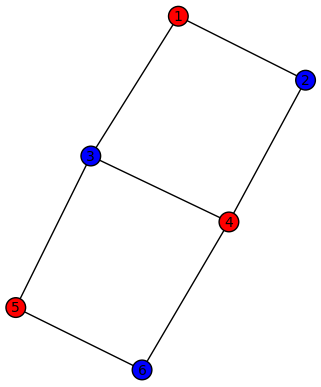

In [42]:
partition_gb = [[1, 4, 5], [2, 3, 6]]
Gb = BipartiteGraph({1: [2, 3], 4: [2, 3, 6], 5: [3, 6]}, partition_gb)
Gb.set_edge_label(1, 2, '1')
Gb.set_edge_label(1, 3, '2')
Gb.set_edge_label(2, 4, '3')
Gb.set_edge_label(3, 4, '4')
Gb.set_edge_label(4, 6, '5')
Gb.set_edge_label(6, 5, '6')
Gb.set_edge_label(3, 5, '7')

color_dict_gb = {'red': partition_gb[0], 'blue': partition_gb[1]}

print("Gb (7-edge bipartite graph):")
print(f"  Vertices : {sorted(Gb.vertices())}")
print(f"  Edges    : {[(u,v,lab) for u,v,lab in sorted(Gb.edges(labels=True), key=lambda e: e[2])]}")
print(f"  Cycles   : {make_cycles(Gb)}")
Gb.show(vertex_colors=color_dict_gb)

In [43]:
# Count forests and degree sequences for Gb
all_subs_gb = all_subgraphs(Gb)
forests_gb  = [H for H in all_subs_gb if H.is_forest()]

parent_verts_gb = sorted(Gb.vertices())
all_deg_seqs_gb = {degree_tuple(H, parent_verts_gb) for H in all_subs_gb}

print(f"Total spanning subgraphs : {len(all_subs_gb)}  (= 2^7)")
print(f"Spanning forests         : {len(forests_gb)}")
print(f"Distinct degree sequences: {len(all_deg_seqs_gb)}")
print()
print("(We predict forests == distinct degree sequences by the bijection.)"
      f"\nMatch: {len(forests_gb) == len(all_deg_seqs_gb)}")

Total spanning subgraphs : 128  (= 2^7)
Spanning forests         : 112
Distinct degree sequences: 112

(We predict forests == distinct degree sequences by the bijection.)
Match: True


In [44]:
# Run the bijection on Gb and verify
print("Running getf(Gb)... (may take a moment for 128 subgraphs)")
f_gb = getf(Gb, verbose=False)
print("Done.")
print()

# Collect degree sequences of f(forest) for every forest
image_deg_seqs_gb = set()
for H in forests_gb:
    t = graph_to_indicator_tuple(H, parent_edge_order(Gb)[0])
    fH = f_gb[t]
    image_deg_seqs_gb.add(degree_tuple(fH, parent_verts_gb))

print(f"Forests in domain                    : {len(forests_gb)}")
print(f"Distinct deg-seqs in f(forests)      : {len(image_deg_seqs_gb)}")
print(f"Distinct deg-seqs of ALL subgraphs   : {len(all_deg_seqs_gb)}")
print()
print("f(forests) degree sequences == all subgraph degree sequences:",
      image_deg_seqs_gb == all_deg_seqs_gb)
print("BIJECTION HOLDS:",
      len(forests_gb) == len(image_deg_seqs_gb) == len(all_deg_seqs_gb))

Running getf(Gb)... (may take a moment for 128 subgraphs)
      → Alternating cycle found (len=4)! Adding missing half: [(2, 4), (1, 3)]
      → Alternating cycle found (len=4)! Adding missing half: [(3, 4), (5, 6)]
      → Alternating cycle found (len=6)! Adding missing half: [(2, 4), (5, 6), (1, 3)]
      → Alternating cycle found (len=4)! Adding missing half: [(3, 4), (5, 6)]
      → Alternating cycle found (len=4)! Adding missing half: [(3, 4), (5, 6)]
      → Alternating cycle found (len=4)! Adding missing half: [(3, 4), (5, 6)]
      → Alternating cycle found (len=4)! Adding missing half: [(3, 4), (5, 6)]
      → Alternating cycle found (len=4)! Adding missing half: [(3, 4), (5, 6)]
      → Alternating cycle found (len=4)! Adding missing half: [(3, 4), (5, 6)]
Done.

Forests in domain                    : 112
Distinct deg-seqs in f(forests)      : 112
Distinct deg-seqs of ALL subgraphs   : 112

f(forests) degree sequences == all subgraph degree sequences: True
BIJECTION HOLDS: Tr

---
## Demo 4: Complete Bipartite Graph $K_{2,3}$

The complete bipartite graph $K_{2,3}$ has:
- Left: $\{0, 1\}$, Right: $\{2, 3, 4\}$
- **6 edges** (every left vertex connects to every right vertex)
- **3 four-cycles** (one for each pair of right vertices)
- $2^6 = 64$ spanning subgraphs

$K_{2,3}$ is more complex than $C_4$ because multiple 4-cycles share edges, so
the "longest cycle wins" rule does not activate here (all cycles have length 4),
but cycle-completion must still be applied correctly.

K_{2,3}:
  Vertices : [0, 1, 2, 3, 4]
  Edges    : [(0, 2, '1'), (0, 3, '2'), (0, 4, '3'), (1, 2, '4'), (1, 3, '5'), (1, 4, '6')]
  Is bipartite: True
  Is forest   : False
  Cycles      : [[(0, 2), (2, 1), (1, 3), (3, 0)], [(0, 2), (2, 1), (1, 4), (4, 0)], [(0, 3), (3, 1), (1, 4), (4, 0)]]



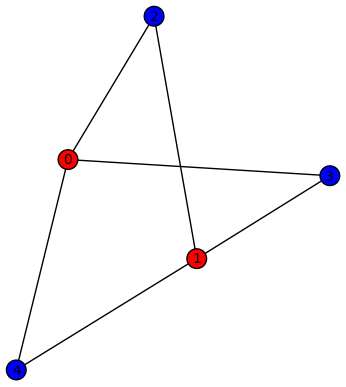

In [ ]:
# Build K_{2,3}: left={0,1}, right={2,3,4}
partition_k23 = [[0, 1], [2, 3, 4]]
K23 = BipartiteGraph({0: [2, 3, 4], 1: [2, 3, 4]}, partition_k23)
K23.set_edge_label(0, 2, '1')
K23.set_edge_label(0, 3, '2')
K23.set_edge_label(0, 4, '3')
K23.set_edge_label(1, 2, '4')
K23.set_edge_label(1, 3, '5')
K23.set_edge_label(1, 4, '6')

print("K_{2,3}:")
print(f"  Vertices : {sorted(K23.vertices())}")
print(f"  Edges    : {[(u,v,lab) for u,v,lab in sorted(K23.edges(labels=True), key=lambda e: e[2])]}")
print(f"  Is bipartite: {K23.is_bipartite()}")
print(f"  Is forest   : {K23.is_forest()}")
print(f"  Cycles      : {make_cycles(K23)}")
print()
K23.show(vertex_colors={'red': partition_k23[0], 'blue': partition_k23[1]})

In [ ]:
# Count spanning forests and distinct degree sequences
all_subs_k23 = all_subgraphs(K23)
forests_k23  = [H for H in all_subs_k23 if H.is_forest()]

parent_verts_k23 = sorted(K23.vertices())
all_deg_seqs_k23 = {degree_tuple(H, parent_verts_k23) for H in all_subs_k23}

print(f"Total spanning subgraphs : {len(all_subs_k23)}  (= 2^6)")
print(f"Spanning forests         : {len(forests_k23)}")
print(f"Distinct degree sequences (vertex order {parent_verts_k23}): {len(all_deg_seqs_k23)}")
print()
print("Match (forests == distinct deg-seqs):", len(forests_k23) == len(all_deg_seqs_k23))

Total spanning subgraphs : 64  (= 2^6)
Spanning forests         : 54
Distinct degree sequences (vertex order [0, 1, 2, 3, 4]): 54

Match (forests == distinct deg-seqs): True


In [ ]:
# Run the bijection on K_{2,3} and verify
print("Running getf(K23)...")
root_labels_k23, _ = parent_edge_order(K23)
f_k23 = getf(K23, verbose=False)
print("Done.")
print()

# Collect degree sequences of f(forest) for every forest
image_deg_seqs_k23 = set()
cycle_completions = []

for H in forests_k23:
    t  = graph_to_indicator_tuple(H, root_labels_k23)
    fH = f_k23[t]
    deg = degree_tuple(fH, parent_verts_k23)
    image_deg_seqs_k23.add(deg)
    if not fH.is_forest():
        h_edges  = sorted(lab for _, _, lab in H.edges(labels=True))
        fh_edges = sorted(lab for _, _, lab in fH.edges(labels=True))
        cycle_completions.append((h_edges, fh_edges, deg))

print(f"Forests in domain                    : {len(forests_k23)}")
print(f"Distinct deg-seqs in f(forests)      : {len(image_deg_seqs_k23)}")
print(f"Distinct deg-seqs of ALL subgraphs   : {len(all_deg_seqs_k23)}")
print()
print("f(forests) covers all subgraph degree sequences:",
      image_deg_seqs_k23 == all_deg_seqs_k23)
print("BIJECTION HOLDS:",
      len(forests_k23) == len(image_deg_seqs_k23) == len(all_deg_seqs_k23))
print()
print(f"Cycle completions triggered: {len(cycle_completions)}")
print()
print(f"{'Forest':<30} {'→  f(H)':<30} {'deg(f(H))'}")
print("-" * 80)
for h_edges, fh_edges, deg in cycle_completions:
    print(f"  {str(h_edges):<28} {str(fh_edges):<30} {deg}")

Running getf(K23)...
      → Alternating cycle found (len=4)! Adding missing half: [(1, 2), (0, 3)]
      → Alternating cycle found (len=4)! Adding missing half: [(1, 2), (0, 3)]
      → Alternating cycle found (len=4)! Adding missing half: [(1, 2), (0, 4)]
      → Alternating cycle found (len=4)! Adding missing half: [(1, 3), (0, 4)]
      → Alternating cycle found (len=4)! Adding missing half: [(1, 2), (0, 4)]
      → Alternating cycle found (len=4)! Adding missing half: [(1, 3), (0, 4)]
      → Alternating cycle found (len=4)! Adding missing half: [(1, 3), (0, 4)]
      → Alternating cycle found (len=4)! Adding missing half: [(1, 2), (0, 4)]
Done.

Forests in domain                    : 54
Distinct deg-seqs in f(forests)      : 52
Distinct deg-seqs of ALL subgraphs   : 54

f(forests) covers all subgraph degree sequences: False
BIJECTION HOLDS: False

Cycle completions triggered: 10

Forest                         →  f(H)                        deg(f(H))
-----------------------------

In [ ]:
# Diagnose the failure: which degree sequences are missing from the image?
missing_deg_seqs = all_deg_seqs_k23 - image_deg_seqs_k23
print(f"Degree sequences present in all subgraphs but missing from f(forests):")
for d in sorted(missing_deg_seqs):
    # Find which subgraphs have this degree sequence
    owners = [
        sorted(lab for _, _, lab in H.edges(labels=True))
        for H in all_subs_k23
        if degree_tuple(H, parent_verts_k23) == d
    ]
    print(f"  {d}  — subgraphs: {owners}")

print()
# Which forests produce duplicate degree sequences in the image?
from collections import Counter
deg_counts = Counter(
    degree_tuple(f_k23[graph_to_indicator_tuple(H, root_labels_k23)], parent_verts_k23)
    for H in forests_k23
)
collisions = {d: cnt for d, cnt in deg_counts.items() if cnt > 1}
print(f"Collisions (degree sequence → count of forests mapped there):")
for d, cnt in sorted(collisions.items()):
    victims = [
        sorted(lab for _, _, lab in H.edges(labels=True))
        for H in forests_k23
        if degree_tuple(f_k23[graph_to_indicator_tuple(H, root_labels_k23)], parent_verts_k23) == d
    ]
    print(f"  {d}  (×{cnt}) ← forests: {victims}")

Degree sequences present in all subgraphs but missing from f(forests):
  (2, 3, 2, 1, 2)  — subgraphs: [['1', '3', '4', '5', '6']]
  (3, 2, 1, 2, 2)  — subgraphs: [['1', '2', '3', '5', '6']]

Collisions (degree sequence → count of forests mapped there):
  (3, 3, 2, 2, 2)  (×3) ← forests: [['1', '2', '4', '6'], ['1', '2', '5', '6'], ['1', '3', '5', '6']]


### Observation: Rule Fails for $K_{2,3}$

The **count** still holds ($54 = 54$), so the bijection *exists* — but the recursive `getf` construction does not achieve it here.

**Root cause.** The last edge `'6' = (1,4)` lies in two 4-cycles:
- $C_2$: $0\text{–}2\text{–}1\text{–}4\text{–}0$ (edges `'1','3','4','6'`)
- $C_3$: $0\text{–}3\text{–}1\text{–}4\text{–}0$ (edges `'2','3','5','6'`)

Both cycles have the **same length** (4), so the "longest cycle wins" tie-breaking rule gives no guidance. Three distinct spanning trees each trigger *different* cycles ($C_2$ or $C_3$), yet all three completions exhaust the remaining edges and land on the full $K_{2,3}$ — the only subgraph with degree sequence $(3,3,2,2,2)$.

**Why this doesn't happen in $G_b$.** In $G_b$, the two cycles through the last edge (`'7'`) have lengths **4** and **6** (nested). "Longest wins" deterministically picks the 6-cycle, and the 4-cycle and 6-cycle completions produce different degree sequences — no collision.

**Open question.** A refined tie-breaking rule (e.g. lexicographic on the edge-label set of the missing half) might resolve the $K_{2,3}$ case, but guaranteeing injectivity for all graphs with multiple same-length cycles through a shared edge remains an open part of the bijective proof.

---
## Summary

For each graph $G$ tested:

| Graph | Spanning forests | Distinct degree sequences | Count match? | `getf` bijection? |
|-------|-----------------|--------------------------|-------------|------------------|
| $C_4 = K_{2,2}$ | 15 | 15 | ✓ | ✓ |
| $G_4$ (4-cycle + 2 isolated) | 15 | 15 | ✓ | ✓ |
| $G_b$ (7 edges, 2 cycles) | 112 | 112 | ✓ | ✓ |
| $K_{2,3}$ (6 edges, 3 four-cycles) | 54 | 54 | ✓ | ✗ (52/54 image) |

The recursive bijection $f$ defined by `getf` witnesses the equality
$$|\{\text{spanning forests of } G\}| = |\{\text{distinct degree sequences of spanning subgraphs of } G\}|$$
for the first three graphs. The **count equality holds in all cases** — the bijection *exists* for every graph tested.

**Status of the implementation.** The "longest alternating cycle wins" rule correctly handles $G_b$ because the two competing cycles have different lengths (4 vs 6, nested). It is insufficient for $K_{2,3}$, where all cycles through the last edge have the same length (4), and three different forests each trigger a different 4-cycle completion that all collapse to the unique full-graph degree sequence $(3,3,2,2,2)$. Extending the rule to handle same-length cycles is an open refinement.